- Paper: Do Student Debt Relief Policies affect Pre-College Behaviour? Evidence from New York's "Get on Your Feet" Program
- Author: Dui J. Davidsson 
- Date: December 19th, 2025

In [230]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import statsmodels.api as sm
from functools import reduce
import statsmodels.formula.api as smf

Loading in of datasets: 
 - NYCED Report Card Database "High School Post-Graduation Plans of Completers"
 - NYCED Report Card Database "Demographic Factors"
 - NYCED Report Card Database "High School Completers"
 - NYCED Report Card Database "Staff" 


Note: To load dataframe, each dataaset was converted from an .mdb Microsoft Acsess file to .csv using an external Homebrew package entitiled "MDBTools" outside of this notebook

In [427]:
# Data years: 2013-2017
years = range(2009, 2018)

## Reading in of "High School Post-Graduation Plans of Completers" for all years
hscomp = {y: pd.read_csv(f"High_School_Post-Graduation_Plans_of_Completers{y}.csv")
          for y in years}

## Reading in of "High School Post-Graduation Plans of Completers" for all years
dgraph = {y: pd.read_csv(f"Demographic_Factors{y}.csv")
          for y in years} 

## Reading in of "High School Completers" for all years
hscomp2 = {y: pd.read_csv(f"High_School_Completers{y}.csv")
          for y in years} 

## Reading in of "School Staff" for all years
staff = {y: pd.read_csv(f"Staff{y}.csv")
          for y in years} 

Filtering and merging of datasets into one set of panel dataset for NY highschools, with columns for all variables

In [428]:
## datasets contain data on all schools at different levels (elementary, high schools, counties, school districts)
## Also contains statistics for all students, general education students, and students with disabilities


## Defining function for filtering for NY highschools, statistics for all students, and the specific year of the plans dataset
def keep_hs_all(df, year, school_col="ENTITY_NAME", subgroup_col="SUBGROUP_NAME", year_col="YEAR"):
    cols = {c.strip(): c for c in df.columns} 
    df = df.rename(columns=cols)
    ## Mask for filtering for NY high schools
    school_mask = df[school_col].astype(str).str.contains("HIGH SCHOOL", case=False, na=False)
    ## Mask for filtering for all students statistics
    subgroup_mask = (
        df[subgroup_col]
        .astype(str)
        .str.strip()
        .str.casefold()
        .str.contains("all students", na=False)
    )
    ## Mask for filtering for specific dataset year
    year_mask = df[year_col].astype(int) == int(year)
    return df[school_mask & subgroup_mask & year_mask]

## Contruction of filtered post-graduation plans datsets
hscomp_hs_all = {y: keep_hs_all(df, year = y) for y, df in hscomp.items()}
hscomp2_hs_all =  {y: keep_hs_all(df, year = y) for y, df in hscomp2.items()}

## Defining function for filtering for NY highschools, and the specific year of the demographics dataset
def filter_school_year(df, year, school_col = "ENTITY_NAME", year_col="YEAR",
                       school_pattern="HIGH SCHOOL"):
    school_mask = df[school_col].astype(str).str.contains(school_pattern, case=False, na=False)
    year_mask = df[year_col].astype(int) == int(year)
    return df[school_mask & year_mask]

## Contruction of filtered demographic factors datasets
dgraph_hs_all = {y: filter_school_year(df, year=y) for y, df in dgraph.items()}
staff_hs_all = {y: filter_school_year(df, year=y) for y, df in staff.items()}


In [429]:
# Merging of all years in each datasetto derive panel datasets for both plans demographics data
hscomp_all = pd.concat(hscomp_hs_all.values(), ignore_index=True)
hscomp2_all = pd.concat(hscomp2_hs_all.values(), ignore_index=True)
dgraph_all = pd.concat(dgraph_hs_all.values(), ignore_index=True)
staff_all = pd.concat(staff_hs_all.values(), ignore_index=True)


#  Merging of plans dataset and demographics data into one single panel dataset

dataframe1 = hscomp_all.merge(
    dgraph_all,
    on=["ENTITY_NAME", "YEAR"],
    how="outer",
    suffixes=("_hs", "_dg"),
)

dataframe2 = hscomp2_all.merge(
    staff_all,
    on=["ENTITY_NAME", "YEAR"],
    how="outer",
    suffixes=("_hs2", "_stf"),
)

dataframe = dataframe1.merge(
    dataframe2,
    on=["ENTITY_NAME", "YEAR"],
    how="outer",
    suffixes=("_1", "_2"),
)

## Defining function for coering coloumns of merged panel dataset into their appropiate types
def coerce_int_after(df, start_col):
    cols = df.columns
    if start_col not in cols:
        raise KeyError(f"{start_col} not in columns")
    idx = cols.get_loc(start_col)
    target_cols = cols[idx + 1 :]  # everything after start_col
    df[target_cols] = df[target_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")
    return df

## Coersion of types into merged panel dataset
dataframe = coerce_int_after(dataframe, start_col="SUBGROUP_NAME_1")

dataframe

,ENTITY_CD_hs,ENTITY_NAME,YEAR,SUBGROUP_NAME_1,NUM_4YR_COLLEGE_IN_STATE,PER_4YR_COLLEGE_IN_STATE,NUM_4YR_COLLEGE_OUT_STATE,PER_4YR_COLLEGE_OUT_STATE,NUM_2YR_COLLEGE_IN_STATE,PER_2YR_COLLEGE_IN_STATE,...,PER_TURN_FIVE_YRS,PER_TURN_ALL,NUM_FT_OTH_PROF_STAFF,NUM_PT_OTH_PROF_STAFF,NUM_FT_PARAPROFESSIONALS,NUM_PT_PARAPROFESSIONALS,NUM_FT_ASST_PRINCIPALS,NUM_PT_ASST_PRINCIPALS,NUM_FT_PRINCIPALS,NUM_PT_PRINCIPALS
0,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2009,All Students,114,40,30,11,53,19,...,25,19,8,1,<NA>,<NA>,7,0,1,0
1,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2010,All Students,80,35,24,10,50,22,...,20,18,9,0,0,0,6,1,1,0
2,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2011,All Students,152,49,22,7,82,26,...,38,18,12,1,0,0,4,0,1,0
3,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2012,All Students,108,45,21,9,60,25,...,0,44,9,0,0,0,6,0,1,0
4,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2013,All Students,80,29,9,3,45,16,...,14,15,8,0,0,0,5,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8636,6.624021e+11,YORKTOWN HIGH SCHOOL,2013,All Students,116,36,129,40,49,15,...,50,8,14,0,0,0,3,0,1,0
8637,6.624021e+11,YORKTOWN HIGH SCHOOL,2014,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0,4,14,0,0,0,3,0,1,0
8638,6.624021e+11,YORKTOWN HIGH SCHOOL,2015,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,12,1,0,0,3,0,1,0
8639,6.624021e+11,YORKTOWN HIGH SCHOOL,2016,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,10,0,0,0,3,0,1,0


Derivation of summary statistics table comparing average college-going rate across covariate for schools who have twice as many in-state college goers as out-of-state college goers between 2009-2013, where this data is available (Tables 1 and 2)

In [431]:
## Copying of dataframe to new variable
instatesum = dataframe.copy()

## Filtering of dataset for only the 2013 year, where in-state and out-of-state number exist
instatesum = instatesum[instatesum["YEAR"].between(2009,2013)]

## Filtering out schools with missing covariate values
instatesum = instatesum.dropna(subset=["NUM_4YR_COLLEGE_IN_STATE", "NUM_4YR_COLLEGE_OUT_STATE", "NUM_2YR_COLLEGE_IN_STATE", "NUM_2YR_COLLEGE_OUT_STATE"])

## Derivation of two dummies for 4-year and 2-year college-goers, where dummy is equal to 1 if the rate of in-state college-goers is twice the rate 
## of out-of-state college-goers

instatesum["4YR_IN_STATE_DUMMY"] = np.where(
    instatesum["PER_4YR_COLLEGE_IN_STATE"] > 2*instatesum["PER_4YR_COLLEGE_OUT_STATE"],
    1, 
    0             
)

instatesum["2YR_IN_STATE_DUMMY"] = np.where(
    instatesum["PER_2YR_COLLEGE_IN_STATE"] > 2*instatesum["PER_2YR_COLLEGE_OUT_STATE"],
    1, 
    0             
)

## Definition of covariates in summery table
cols = ["PER_FREE_LUNCH", "PER_REDUCED_LUNCH", "PER_LEP", "PER_AM_IND", "PER_BLACK", "PER_HISP", "PER_WHITE", "PER_ASIAN", "PER_Multi", "PER_FEMALE", "PER_ECDIS"]

# Group of schools with 4-year in-state college dummy, and derivation of the mean in-state college going rate relative to defined covariates
summary = (
    instatesum
    .groupby("4YR_IN_STATE_DUMMY")[cols]
    .agg(["mean", "std", "count"])
)

print(summary)


                   PER_FREE_LUNCH                   PER_REDUCED_LUNCH  \
                             mean         std count              mean   
4YR_IN_STATE_DUMMY                                                      
0                       23.183319   26.347351  1151          5.199826   
1                       42.543743  113.437581  3452          8.211761   

                                     PER_LEP                  PER_AM_IND  ...  \
                         std count      mean        std count       mean  ...   
4YR_IN_STATE_DUMMY                                                        ...   
0                   4.393675  1151  3.009557   7.358219  1151   0.286707  ...   
1                   7.987389  3452  8.707126  84.692183  3452   0.597914  ...   

                   PER_ASIAN PER_Multi                 PER_FEMALE            \
                       count      mean       std count       mean       std   
4YR_IN_STATE_DUMMY                                                    

In [432]:
# Group of schools with 2-year in-state college dummy, and derivation of the mean in-state college going rate relative to defined covariates
summary = (
    instatesum
    .groupby("2YR_IN_STATE_DUMMY")[cols]
    .agg(["mean", "std", "count"])
)

print(summary)

                   PER_FREE_LUNCH                   PER_REDUCED_LUNCH  \
                             mean         std count              mean   
2YR_IN_STATE_DUMMY                                                      
0                       50.460123   29.734057   163           7.08589   
1                       37.234234  101.085443  4440          7.472297   

                                     PER_LEP                  PER_AM_IND  ...  \
                         std count      mean        std count       mean  ...   
2YR_IN_STATE_DUMMY                                                        ...   
0                   4.927122   163  8.239264  12.771416   163   0.503067  ...   
1                   7.447989  4440  7.247297   74.77069  4440   0.520721  ...   

                   PER_ASIAN PER_Multi                 PER_FEMALE            \
                       count      mean       std count       mean       std   
2YR_IN_STATE_DUMMY                                                    

First estimation method: Regression of 2-year and 4-year in-state college-going rates on school socio-economic charecterisitcs pre-policy years (2009-2013, when in-state data is avialable) to later fit predicted estimates to our relevant policy years.

In [498]:
## Dropping of NA observations
instatesum = instatesum.dropna(subset = ["PER_NO_VALID_CERT", "PER_TEACH_OUT_CERT", "PER_FEWER_3YRS_EXP", "PER_NOT_HQ"])

## Model form for 4-year college rate 
formula = """
PER_4YR_COLLEGE_IN_STATE ~
              + PER_FREE_LUNCH
              + PER_REDUCED_LUNCH
              + PER_LEP
              + PER_BLACK
              + PER_HISP
              + PER_ASIAN
              + PER_EMPLOYMENT
              + PER_OTHER
              + PER_UNKNOWN
"""

## Defining of WLS regression, with total graduating cohort size as weights
wls_4yr_pre = smf.wls(
    formula=formula,
    data=instatesum,
    weights=instatesum["HSGraduates"]
)

## Fitting of regression, with errors clustered by school
wls_4yr_pre_fit = wls_4yr_pre.fit(
    cov_type="cluster",
    cov_kwds={"groups": instatesum["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_4yr_pre_fit.summary2().tables[1]  
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)

## Printing of regression results
print(coef_tbl[mask])

                       Coef.  Std.Err.          z         P>|z|     [0.025  \
Intercept          43.109941  0.842453  51.171920  0.000000e+00  41.458763   
PER_FREE_LUNCH      0.000245  0.006125   0.040018  9.680785e-01  -0.011760   
PER_REDUCED_LUNCH   0.053368  0.085027   0.627667  5.302222e-01  -0.113281   
PER_LEP            -0.008372  0.004304  -1.945128  5.175952e-02  -0.016807   
PER_BLACK          -0.047757  0.024107  -1.981074  4.758296e-02  -0.095006   
PER_HISP            0.003794  0.021011   0.180594  8.566861e-01  -0.037386   
PER_ASIAN           0.348016  0.048113   7.233364  4.711748e-13   0.253717   
PER_EMPLOYMENT     -0.946076  0.058577 -16.150988  1.117581e-58  -1.060885   
PER_OTHER          -0.914075  0.184112  -4.964770  6.878255e-07  -1.274929   
PER_UNKNOWN        -0.440822  0.033035 -13.344224  1.279973e-40  -0.505569   

                      0.975]  
Intercept          44.761119  
PER_FREE_LUNCH      0.012250  
PER_REDUCED_LUNCH   0.220018  
PER_LEP          

In [435]:
## Model form for 2-year college rate 
formula = """
PER_2YR_COLLEGE_IN_STATE ~
              + PER_FREE_LUNCH
              + PER_REDUCED_LUNCH
              + PER_LEP
              + PER_BLACK
              + PER_HISP
              + PER_ASIAN
              + PER_MILITARY
              + PER_EMPLOYMENT
              + PER_UNKNOWN
"""

## Defining of WLS regression, with total graduating cohort size as weights
wls_2yr_pre = smf.wls(
    formula=formula,
    data=instatesum,
    weights=instatesum["HSGraduates"]
)

## Fitting of regression, with errors clustered by school
wls_2yr_pre_fit = wls_2yr_pre.fit(
    cov_type="cluster",
    cov_kwds={"groups": instatesum["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_2yr_pre_fit.summary2().tables[1]  # DataFrame of coefficients
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                       Coef.  Std.Err.          z         P>|z|     [0.025  \
Intercept          24.171504  1.223888  19.749775  8.057565e-87  21.772729   
PER_FREE_LUNCH     -0.019922  0.009156  -2.175709  2.957704e-02  -0.037868   
PER_REDUCED_LUNCH   0.288108  0.128667   2.239181  2.514417e-02   0.035926   
PER_LEP             0.012158  0.003597   3.379792  7.254080e-04   0.005108   
PER_BLACK           0.154323  0.023465   6.576581  4.813891e-11   0.108331   
PER_HISP            0.127526  0.027744   4.596576  4.294906e-06   0.073149   
PER_ASIAN          -0.227673  0.048208  -4.722727  2.327034e-06  -0.322159   
PER_MILITARY        1.853873  0.255754   7.248644  4.209649e-13   1.352603   
PER_EMPLOYMENT      0.484015  0.089900   5.383915  7.288285e-08   0.307814   
PER_UNKNOWN        -0.296088  0.024110 -12.280836  1.148058e-34  -0.343343   

                      0.975]  
Intercept          26.570280  
PER_FREE_LUNCH     -0.001975  
PER_REDUCED_LUNCH   0.540290  
PER_LEP          

Second estimation method: averging of in-state enrollment across pre-policy years and assignment of schools above the 50% threshold to the "treatment group".

In [ ]:
## Definiing of pre-policy years
pre_years = [2009, 2010, 2011, 2012, 2013]

## Derivation of new dataframe with each schools average 4-year in-state share mean across observations
baseline4yr = (
    instatesum[instatesum["YEAR"].isin(pre_years)]
      .groupby("ENTITY_NAME", as_index=False)["PER_4YR_COLLEGE_IN_STATE"]
      .mean()
      .rename(columns={"PER_4YR_COLLEGE_IN_STATE": "instate_pre_mean"})
)

## Defining of treatment group: indicator varible for schools with average 4-year in-state share mean above 50%
baseline4yr["4yrtrendsdummy"] = (baseline4yr["instate_pre_mean"] > 50).astype(int)

# merge onto your full panel (whatever dataframe has all years)
dataframe = dataframe.merge(baseline4yr[["ENTITY_NAME", "4yrtrendsdummy"]], on="ENTITY_NAME", how="left")

## Derivation of new dataframe with each schools average 2-year in-state share mean across observations
baseline2yr = (
    instatesum[instatesum["YEAR"].isin(pre_years)]
      .groupby("ENTITY_NAME", as_index=False)["PER_2YR_COLLEGE_IN_STATE"]
      .mean()
      .rename(columns={"PER_2YR_COLLEGE_IN_STATE": "instate_pre_mean"})
)

## Defining of treatment group: indicator varible for schools with average 2-year in-state share mean above 50%
baseline2yr["2yrtrendsdummy"] = (baseline2yr["instate_pre_mean"] > 50).astype(int)

# merge onto your full panel (whatever dataframe has all years)
dataframe = dataframe.merge(baseline2yr[["ENTITY_NAME", "2yrtrendsdummy"]], on="ENTITY_NAME", how="left")


,ENTITY_CD_hs,ENTITY_NAME,YEAR,SUBGROUP_NAME_1,NUM_4YR_COLLEGE_IN_STATE,PER_4YR_COLLEGE_IN_STATE,NUM_4YR_COLLEGE_OUT_STATE,PER_4YR_COLLEGE_OUT_STATE,NUM_2YR_COLLEGE_IN_STATE,PER_2YR_COLLEGE_IN_STATE,...,NUM_FT_OTH_PROF_STAFF,NUM_PT_OTH_PROF_STAFF,NUM_FT_PARAPROFESSIONALS,NUM_PT_PARAPROFESSIONALS,NUM_FT_ASST_PRINCIPALS,NUM_PT_ASST_PRINCIPALS,NUM_FT_PRINCIPALS,NUM_PT_PRINCIPALS,4yrtrendsdummy,2yrtrendsdummy
0,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2009,All Students,114,40,30,11,53,19,...,8,1,<NA>,<NA>,7,0,1,0,0.0,0.0
1,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2010,All Students,80,35,24,10,50,22,...,9,0,0,0,6,1,1,0,0.0,0.0
2,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2011,All Students,152,49,22,7,82,26,...,12,1,0,0,4,0,1,0,0.0,0.0
3,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2012,All Students,108,45,21,9,60,25,...,9,0,0,0,6,0,1,0,0.0,0.0
4,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2013,All Students,80,29,9,3,45,16,...,8,0,0,0,5,0,1,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8636,6.624021e+11,YORKTOWN HIGH SCHOOL,2013,All Students,116,36,129,40,49,15,...,14,0,0,0,3,0,1,0,0.0,0.0
8637,6.624021e+11,YORKTOWN HIGH SCHOOL,2014,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,14,0,0,0,3,0,1,0,0.0,0.0
8638,6.624021e+11,YORKTOWN HIGH SCHOOL,2015,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,12,1,0,0,3,0,1,0,0.0,0.0
8639,6.624021e+11,YORKTOWN HIGH SCHOOL,2016,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,10,0,0,0,3,0,1,0,0.0,0.0


Filtering and cleaning of dataset for use in regressions, and fitting of SES regression to derive the $EligShare_s$ predicted in-state shares

In [499]:

## Defining of relevant covariates used in constuction of the composite index
elig_cols = ["PER_FREE_LUNCH", "PER_REDUCED_LUNCH", "PER_BLACK", "PER_HISP"]

## Copying to new dataset
hs_schools = dataframe.copy()

## Merging of in-state and out-of-state college going rates in 2013 year for standardized college-going rate across years

hs_schools["PER_4YR_COLLEGE"] = np.where(
    hs_schools["PER_4YR_COLLEGE"].isna(),
    (hs_schools["PER_4YR_COLLEGE_IN_STATE"] + hs_schools["PER_4YR_COLLEGE_OUT_STATE"]), 
    hs_schools["PER_4YR_COLLEGE"]             
)

hs_schools["PER_2YR_COLLEGE"] = np.where(
    hs_schools["PER_2YR_COLLEGE"].isna(),
    (hs_schools["PER_2YR_COLLEGE_IN_STATE"] + hs_schools["PER_2YR_COLLEGE_OUT_STATE"]), 
    hs_schools["PER_2YR_COLLEGE"]             
)

## Loop for combining the coloumns of English Language Learner (ELL), present in 2014-2017 years, and the coloumns on rates for Limited
## English Proficicency (LEP), present in the 2013 data year, into one coloumn
for col in ["PER_LEP", "PER_ELL"]:
    hs_schools[col] = pd.to_numeric(hs_schools[col], errors="coerce")


hs_schools["PER_LEP"] = hs_schools["PER_ELL"].combine_first(hs_schools["PER_LEP"])

## Creation of post policy dummy variable
hs_schools["Post"] = (hs_schools["YEAR"] >= 2015).astype(int)

## Dropping of observations with missing covariates

hs_schools = hs_schools.dropna(subset=["ENTITY_CD_hs", "PER_4YR_COLLEGE", "PER_2YR_COLLEGE"])

## Creation of EligShare values using fitted prediction from pre-policy years

hs_schools["EligShare_4YR"] = np.where(
    hs_schools["PER_4YR_COLLEGE_IN_STATE"].isna(),
    wls_4yr_pre_fit.predict(hs_schools),
    hs_schools["PER_4YR_COLLEGE_IN_STATE"])

hs_schools["EligShare_2YR"] = np.where(
    hs_schools["PER_2YR_COLLEGE_IN_STATE"].isna(),
    wls_2yr_pre_fit.predict(hs_schools),
    hs_schools["PER_2YR_COLLEGE_IN_STATE"])

## Creation of trends dummy by extrapolating average in-state college rate to policy relevent years

hs_schools = hs_schools.dropna(subset = ["4yrtrendsdummy", "2yrtrendsdummy"])

for out_col, src_col in [
    ("4yrtrendsdummy", "PER_4YR_COLLEGE_IN_STATE"),
    ("2yrtrendsdummy", "PER_2YR_COLLEGE_IN_STATE"),
]:
    hs_schools[out_col] = hs_schools[out_col].astype("Int64") 
    mask = hs_schools[src_col].notna()
    hs_schools.loc[mask, out_col] = (
        hs_schools.loc[mask, src_col] >= 50
    ).astype("Int64")

hs_schools["EligShare_4YR"] = hs_schools["EligShare_4YR"].where(hs_schools["EligShare_4YR"] >= 0, 0)
hs_schools["EligShare_2YR"] = hs_schools["EligShare_2YR"].where(hs_schools["EligShare_2YR"] >= 0, 0)

hs_schools["EligShare_4YR_dummy"] = (hs_schools["EligShare_4YR"] >= 50).astype(int)
hs_schools["EligShare_2YR_dummy"] = (hs_schools["EligShare_2YR"] >= 50).astype(int)

hs_schools

,ENTITY_CD_hs,ENTITY_NAME,YEAR,SUBGROUP_NAME_1,NUM_4YR_COLLEGE_IN_STATE,PER_4YR_COLLEGE_IN_STATE,NUM_4YR_COLLEGE_OUT_STATE,PER_4YR_COLLEGE_OUT_STATE,NUM_2YR_COLLEGE_IN_STATE,PER_2YR_COLLEGE_IN_STATE,...,NUM_PT_ASST_PRINCIPALS,NUM_FT_PRINCIPALS,NUM_PT_PRINCIPALS,4yrtrendsdummy,2yrtrendsdummy,Post,EligShare_4YR,EligShare_2YR,EligShare_4YR_dummy,EligShare_2YR_dummy
0,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2009,All Students,114,40,30,11,53,19,...,0,1,0,0,0,0,40.000000,19.000000,0,0
1,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2010,All Students,80,35,24,10,50,22,...,1,1,0,0,0,0,35.000000,22.000000,0,0
2,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2011,All Students,152,49,22,7,82,26,...,0,1,0,0,0,0,49.000000,26.000000,0,0
3,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2012,All Students,108,45,21,9,60,25,...,0,1,0,0,0,0,45.000000,25.000000,0,0
4,3.106000e+11,A PHILIP RANDOLPH CAMPUS HIGH SCHOOL,2013,All Students,80,29,9,3,45,16,...,0,1,0,0,0,0,29.000000,16.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8636,6.624021e+11,YORKTOWN HIGH SCHOOL,2013,All Students,116,36,129,40,49,15,...,0,1,0,0,0,0,36.000000,15.000000,0,0
8637,6.624021e+11,YORKTOWN HIGH SCHOOL,2014,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0,1,0,0,0,0,41.020586,24.039312,0,0
8638,6.624021e+11,YORKTOWN HIGH SCHOOL,2015,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0,1,0,0,0,1,40.600553,25.673387,0,0
8639,6.624021e+11,YORKTOWN HIGH SCHOOL,2016,All Students,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,0,1,0,0,0,1,41.098783,28.219060,0,0


Derivation of parallel trends chart using the EligShare dummy and the average trends dummy

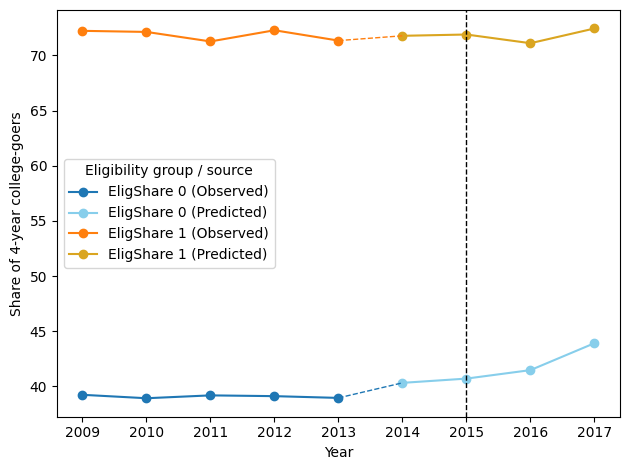

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

## Derivation of datset with average 4-year college going rate for schools between the trends dummy

## Derivation of trends data by averaging in-state college rates across treatment and control group
trend = (
    hs_schools.groupby(["YEAR", "4yrtrendsdummy"])["PER_4YR_COLLEGE"]
      .mean()
      .reset_index()
)
## Defining of observed/predicted categories and their designated colours
colors = {0: "tab:blue", 1: "tab:orange"}
pred_colors = {0: "skyblue", 1: "goldenrod"}

fig, ax = plt.subplots()

## Plotting of trend values
for g in trend["4yrtrendsdummy"].unique():
    sub = trend[trend["4yrtrendsdummy"] == g].sort_values("YEAR")
    pre = sub[sub["YEAR"] <= 2013]
    post = sub[sub["YEAR"] > 2013]

    ax.plot(pre["YEAR"], pre["PER_4YR_COLLEGE"], marker="o",
            color=colors.get(g, "gray"), label=f"EligShare {g} (Observed)")
    ax.plot(post["YEAR"], post["PER_4YR_COLLEGE"], marker="o",
            color=pred_colors.get(g, "lightgray"), linestyle="-",
            label=f"EligShare {g} (Predicted)")

    # dotted connector between last observed and first predicted
    if not pre.empty and not post.empty:
        ax.plot(
            [pre["YEAR"].iloc[-1], post["YEAR"].iloc[0]],
            [pre["PER_4YR_COLLEGE"].iloc[-1], post["PER_4YR_COLLEGE"].iloc[0]],
            color=colors.get(g, "gray"),
            linestyle="--",
            linewidth=1,
        )
## Creation of graph
plt.axvline(2015, color="k", ls="--", lw=1) 
plt.ylabel("Share of 4-year college-goers")
plt.xlabel("Year")
plt.legend(title="Eligibility group / source")
plt.tight_layout()
plt.show()

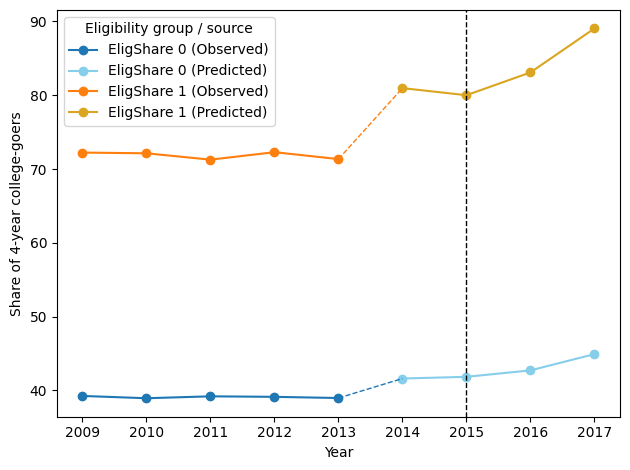

In [ ]:
## Derivation of graph with average 4-year college going rate for schools between the EligShare dummy

## Derivation of trends data by averaging in-state college rates across treatment and control group
trend = (
    hs_schools.groupby(["YEAR", "EligShare_4YR_dummy"])["PER_4YR_COLLEGE"]
      .mean()
      .reset_index()
)
## Defining of observed/predicted categories and their designated colours
colors = {0: "tab:blue", 1: "tab:orange"}
pred_colors = {0: "skyblue", 1: "goldenrod"}

fig, ax = plt.subplots()
## Plotting of trend values
for g in trend["EligShare_4YR_dummy"].unique():
    sub = trend[trend["EligShare_4YR_dummy"] == g].sort_values("YEAR")
    pre = sub[sub["YEAR"] <= 2013]
    post = sub[sub["YEAR"] > 2013]

    ax.plot(pre["YEAR"], pre["PER_4YR_COLLEGE"], marker="o",
            color=colors.get(g, "gray"), label=f"EligShare {g} (Observed)")
    ax.plot(post["YEAR"], post["PER_4YR_COLLEGE"], marker="o",
            color=pred_colors.get(g, "lightgray"), linestyle="-",
            label=f"EligShare {g} (Predicted)")

    # dotted connector between last observed and first predicted
    if not pre.empty and not post.empty:
        ax.plot(
            [pre["YEAR"].iloc[-1], post["YEAR"].iloc[0]],
            [pre["PER_4YR_COLLEGE"].iloc[-1], post["PER_4YR_COLLEGE"].iloc[0]],
            color=colors.get(g, "gray"),
            linestyle="--",
            linewidth=1,
        )
## Creation of graph
plt.axvline(2015, color="k", ls="--", lw=1) 
plt.ylabel("Share of 4-year college-goers")
plt.xlabel("Year")
plt.legend(title="Eligibility group / source")
plt.tight_layout()
plt.show()

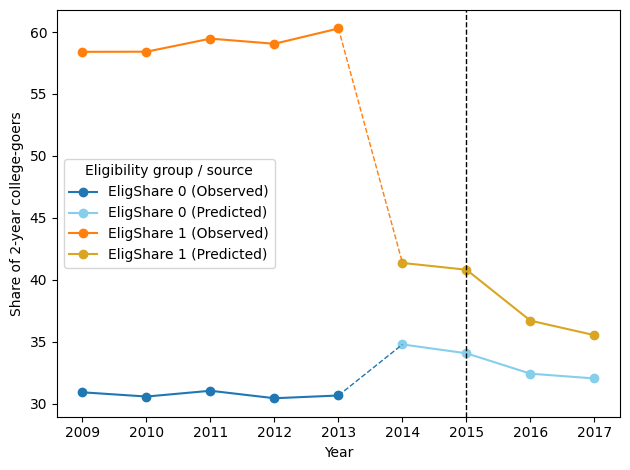

In [ ]:
## Derivation of graph with average 2-year college going rate for schools between the EligShare dummy

## Derivation of trends data by averaging in-state college rates across treatment and control group
trend = (
    hs_schools.groupby(["YEAR", "EligShare_2YR_dummy"])["PER_2YR_COLLEGE"]
      .mean()
      .reset_index()
)
## Defining of observed/predicted categories and their designated colours
colors = {0: "tab:blue", 1: "tab:orange"}
pred_colors = {0: "skyblue", 1: "goldenrod"}

fig, ax = plt.subplots()
## Plotting of trend values
for g in trend["EligShare_2YR_dummy"].unique():
    sub = trend[trend["EligShare_2YR_dummy"] == g].sort_values("YEAR")
    pre = sub[sub["YEAR"] <= 2013]
    post = sub[sub["YEAR"] > 2013]

    ax.plot(pre["YEAR"], pre["PER_2YR_COLLEGE"], marker="o",
            color=colors.get(g, "gray"), label=f"EligShare {g} (Observed)")
    ax.plot(post["YEAR"], post["PER_2YR_COLLEGE"], marker="o",
            color=pred_colors.get(g, "lightgray"), linestyle="-",
            label=f"EligShare {g} (Predicted)")

    # dotted connector between last observed and first predicted
    if not pre.empty and not post.empty:
        ax.plot(
            [pre["YEAR"].iloc[-1], post["YEAR"].iloc[0]],
            [pre["PER_2YR_COLLEGE"].iloc[-1], post["PER_2YR_COLLEGE"].iloc[0]],
            color=colors.get(g, "gray"),
            linestyle="--",
            linewidth=1,
        )
## Creation of graph
plt.axvline(2015, color="k", ls="--", lw=1)  
plt.ylabel("Share of 2-year college-goers")
plt.xlabel("Year")
plt.legend(title="Eligibility group / source")
plt.tight_layout()
plt.show()

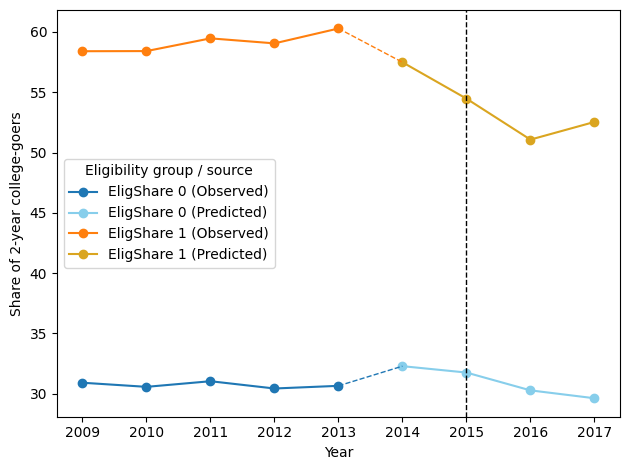

In [ ]:
## Derivation of graph with average 2-year college going rate for schools between the trends dummy

## Derivation of trends data by averaging in-state college rates across treatment and control group
trend = (
    hs_schools.groupby(["YEAR", "2yrtrendsdummy"])["PER_2YR_COLLEGE"]
      .mean()
      .reset_index()
)
## Defining of observed/predicted categories and their designated colours
colors = {0: "tab:blue", 1: "tab:orange"}
pred_colors = {0: "skyblue", 1: "goldenrod"}

fig, ax = plt.subplots()
## Plotting of trend values
for g in trend["2yrtrendsdummy"].unique():
    sub = trend[trend["2yrtrendsdummy"] == g].sort_values("YEAR")
    pre = sub[sub["YEAR"] <= 2013]
    post = sub[sub["YEAR"] > 2013]

    ax.plot(pre["YEAR"], pre["PER_2YR_COLLEGE"], marker="o",
            color=colors.get(g, "gray"), label=f"EligShare {g} (Observed)")
    ax.plot(post["YEAR"], post["PER_2YR_COLLEGE"], marker="o",
            color=pred_colors.get(g, "lightgray"), linestyle="-",
            label=f"EligShare {g} (Predicted)")

    # dotted connector between last observed and first predicted
    if not pre.empty and not post.empty:
        ax.plot(
            [pre["YEAR"].iloc[-1], post["YEAR"].iloc[0]],
            [pre["PER_2YR_COLLEGE"].iloc[-1], post["PER_2YR_COLLEGE"].iloc[0]],
            color=colors.get(g, "gray"),
            linestyle="--",
            linewidth=1,
        )
## Creation of graph
plt.axvline(2015, color="k", ls="--", lw=1)  # policy year marker
plt.ylabel("Share of 2-year college-goers")
plt.xlabel("Year")
plt.legend(title="Eligibility group / source")
plt.tight_layout()
plt.show()

Derivation of WLS Differences-in-Differences regression results for the SES-estimated in-state shares.

In [ ]:
## Years restricted to predicition years: 2014-2017

hs_schoolsses = hs_schools.dropna(subset=["NUM_4YR_COLLEGE", "PER_FEWER_3YRS_EXP"])

## Model form for 4-year college rate, intensity
formula = """
PER_4YR_COLLEGE ~ Post * EligShare_4YR
              + PER_ECDIS
              + PER_SWD
              + PER_FEWER_3YRS_EXP
              + PER_NO_VALID_CERT
              + PER_RegDipAdvDesig 
              + C(ENTITY_CD_hs)
              + C(YEAR)
"""
## Defining of WLS regression, with total graduating cohort size as weights
wls_4yr = smf.wls(
    formula=formula,
    data=hs_schoolsses,
    weights=hs_schoolsses["HSGraduates"]
)

## Fitting of regression, with errors clustered by school ("ENTITY_CD_hs" = school code)
wls_res4 = wls_4yr.fit(
    cov_type="cluster",
    cov_kwds={"groups": hs_schoolsses["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_res4.summary2().tables[1]  
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                       Coef.  Std.Err.         z         P>|z|     [0.025  \
Intercept          -8.562583  4.324491 -1.980021  4.770115e-02 -17.038430   
Post                1.574785  0.954196  1.650378  9.886562e-02  -0.295406   
EligShare_4YR       0.973619  0.127242  7.651699  1.983410e-14   0.724229   
Post:EligShare_4YR -0.014241  0.030076 -0.473497  6.358587e-01  -0.073189   
PER_ECDIS           0.025290  0.027722  0.912278  3.616226e-01  -0.029044   
PER_SWD             0.089911  0.094976  0.946669  3.438074e-01  -0.096239   
PER_FEWER_3YRS_EXP  0.014102  0.051535  0.273638  7.843626e-01  -0.086904   
PER_NO_VALID_CERT  -0.048058  0.152743 -0.314634  7.530397e-01  -0.347428   
PER_RegDipAdvDesig  0.118853  0.038806  3.062793  2.192815e-03   0.042796   

                      0.975]  
Intercept          -0.086737  
Post                3.444975  
EligShare_4YR       1.223009  
Post:EligShare_4YR  0.044707  
PER_ECDIS           0.079625  
PER_SWD             0.276061  
PER_FEWER_3Y

/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 849, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [491]:
## Model form for 4-year college rate, dummy
formula = """
PER_4YR_COLLEGE ~ Post * EligShare_4YR_dummy
              + PER_ECDIS
              + PER_SWD
              + PER_FEWER_3YRS_EXP
              + PER_NO_VALID_CERT
              + PER_RegDipAdvDesig 
              + C(ENTITY_CD_hs)
              + C(YEAR)
"""
## Defining of WLS regression, with total graduating cohort size as weights
wls_4yr = smf.wls(
    formula=formula,
    data=hs_schoolsses,
    weights=hs_schoolsses["HSGraduates"]
)

## Fitting of regression, with errors clustered by school ("ENTITY_CD_hs" = school code)
wls_res4 = wls_4yr.fit(
    cov_type="cluster",
    cov_kwds={"groups": hs_schoolsses["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_res4.summary2().tables[1]  
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                              Coef.  Std.Err.          z         P>|z|  \
Intercept                 26.157295  1.841022  14.208031  8.169007e-46   
Post                       0.690903  0.405174   1.705204  8.815646e-02   
EligShare_4YR_dummy       19.970498  5.990942   3.333449  8.577645e-04   
Post:EligShare_4YR_dummy  -0.710752  0.939170  -0.756787  4.491773e-01   
PER_ECDIS                  0.000508  0.042347   0.011999  9.904266e-01   
PER_SWD                   -0.038548  0.106592  -0.361646  7.176166e-01   
PER_FEWER_3YRS_EXP         0.028253  0.070023   0.403479  6.865956e-01   
PER_NO_VALID_CERT         -0.053437  0.171230  -0.312077  7.549823e-01   
PER_RegDipAdvDesig         0.131261  0.046063   2.849577  4.377735e-03   

                             [0.025     0.975]  
Intercept                 22.548958  29.765631  
Post                      -0.103222   1.485029  
EligShare_4YR_dummy        8.228468  31.712528  
Post:EligShare_4YR_dummy  -2.551493   1.129988  
PER_ECDIS     

/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 849, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [492]:
## Model form for 2-year college rate, intensity
formula = """
PER_2YR_COLLEGE ~ Post * EligShare_2YR
              + PER_ECDIS
              + PER_SWD
              + PER_FEWER_3YRS_EXP
              + PER_NO_VALID_CERT
              + PER_RegDipAdvDesig 
              + C(ENTITY_CD_hs)
              + C(YEAR)
"""

## Defining of WLS regression, with total graduating cohort size as weights
wls_2yr = smf.wls(
    formula=formula,
    data=hs_schoolsses,
    weights=hs_schoolsses["HSGraduates"]
)

## Fitting of regression, with errors clustered by school
wls_res2 = wls_2yr.fit(
    cov_type="cluster",
    cov_kwds={"groups": hs_schoolsses["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_res2.summary2().tables[1]  # DataFrame of coefficients
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                        Coef.  Std.Err.          z         P>|z|     [0.025  \
Intercept           37.829530  2.575395  14.688829  7.601610e-49  32.781850   
Post                 0.699109  0.804420   0.869085  3.848007e-01  -0.877525   
EligShare_2YR        0.512698  0.072805   7.042037  1.894492e-12   0.370002   
Post:EligShare_2YR  -0.077213  0.032486  -2.376778  1.746460e-02  -0.140885   
PER_ECDIS           -0.056151  0.026862  -2.090387  3.658302e-02  -0.108799   
PER_SWD             -0.091815  0.090762  -1.011601  3.117288e-01  -0.269705   
PER_FEWER_3YRS_EXP   0.008279  0.047148   0.175588  8.606175e-01  -0.084130   
PER_NO_VALID_CERT    0.053209  0.198426   0.268156  7.885789e-01  -0.335699   
PER_RegDipAdvDesig  -0.101000  0.035747  -2.825406  4.722076e-03  -0.171063   

                       0.975]  
Intercept           42.877211  
Post                 2.275743  
EligShare_2YR        0.655394  
Post:EligShare_2YR  -0.013541  
PER_ECDIS           -0.003503  
PER_SWD          

/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 849, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [493]:
## Model form for 2-year college rate, dummy
formula = """
PER_2YR_COLLEGE ~ Post * EligShare_2YR_dummy
              + PER_ECDIS
              + PER_SWD
              + PER_FEWER_3YRS_EXP
              + PER_NO_VALID_CERT
              + PER_RegDipAdvDesig 
              + C(ENTITY_CD_hs)
              + C(YEAR)
"""

## Defining of WLS regression, with total graduating cohort size as weights
wls_2yr = smf.wls(
    formula=formula,
    data=hs_schoolsses,
    weights=hs_schoolsses["HSGraduates"]
)

## Fitting of regression, with errors clustered by school
wls_res2 = wls_2yr.fit(
    cov_type="cluster",
    cov_kwds={"groups": hs_schoolsses["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_res2.summary2().tables[1]  # DataFrame of coefficients
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                              Coef.  Std.Err.          z          P>|z|  \
Intercept                 53.303351  1.621705  32.868716  6.154545e-237   
Post                      -1.160764  0.268698  -4.319951   1.560636e-05   
EligShare_2YR_dummy       -1.609515  1.441520  -1.116540   2.641912e-01   
Post:EligShare_2YR_dummy  -3.334709  1.588502  -2.099279   3.579232e-02   
PER_ECDIS                 -0.025939  0.028678  -0.904505   3.657276e-01   
PER_SWD                    0.005818  0.093119   0.062480   9.501807e-01   
PER_FEWER_3YRS_EXP         0.009369  0.050050   0.187199   8.515043e-01   
PER_NO_VALID_CERT          0.006911  0.227770   0.030340   9.757959e-01   
PER_RegDipAdvDesig        -0.119360  0.039478  -3.023439   2.499192e-03   

                             [0.025     0.975]  
Intercept                 50.124868  56.481834  
Post                      -1.687403  -0.634125  
EligShare_2YR_dummy       -4.434843   1.215813  
Post:EligShare_2YR_dummy  -6.448117  -0.221302  
PER_

/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 849, but rank is 10
  warnings.warn('covariance of constraints does not have full '


Second method: assigning schools with average in-state rate above 50 pre-policy to the treatment group.

In [495]:
## Model form for 4-year college rate, trends dummy
formula = """
PER_2YR_COLLEGE ~ Post * Q('4yrtrendsdummy')
              + PER_FREE_LUNCH
              + PER_REDUCED_LUNCH
              + PER_LEP
              + PER_BLACK
              + PER_WHITE
              + PER_ASIAN
              + PER_MILITARY
              + PER_EMPLOYMENT
              + PER_UNKNOWN
              + PER_RegDipAdvDesig 
              + C(ENTITY_CD_hs)
              + C(YEAR)
"""

## Defining of WLS regression, with total graduating cohort size as weights
wls_2yr = smf.wls(
    formula=formula,
    data=hs_schools,
    weights=hs_schools["HSGraduates"]
)

## Fitting of regression, with errors clustered by school
wls_res2 = wls_2yr.fit(
    cov_type="cluster",
    cov_kwds={"groups": hs_schools["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_res2.summary2().tables[1]  # DataFrame of coefficients
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                              Coef.  Std.Err.          z         P>|z|  \
Intercept                 61.619435  3.161044  19.493382  1.249440e-84   
Post                      -1.496368  0.446301  -3.352824  7.999159e-04   
Q('4yrtrendsdummy')       -9.039388  1.023798  -8.829269  1.053625e-18   
Post:Q('4yrtrendsdummy')   2.905765  0.928881   3.128241  1.758558e-03   
PER_FREE_LUNCH             0.006816  0.002621   2.600984  9.295688e-03   
PER_REDUCED_LUNCH         -0.125347  0.040827  -3.070186  2.139254e-03   
PER_LEP                    0.003467  0.000859   4.036588  5.423421e-05   
PER_BLACK                 -0.033901  0.038083  -0.890195  3.733614e-01   
PER_WHITE                  0.000470  0.015137   0.031034  9.752423e-01   
PER_ASIAN                 -0.034315  0.090765  -0.378065  7.053823e-01   
PER_MILITARY              -0.518288  0.094377  -5.491691  3.981023e-08   
PER_EMPLOYMENT            -0.502413  0.042715 -11.761909  6.133168e-32   
PER_UNKNOWN               -0.404988  0

/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 910, but rank is 20
  warnings.warn('covariance of constraints does not have full '


In [497]:
## Model form for 2-year college rate, trends dummy
formula = """
PER_2YR_COLLEGE ~ Post * Q('2yrtrendsdummy')
              + PER_FREE_LUNCH
              + PER_REDUCED_LUNCH
              + PER_LEP
              + PER_BLACK
              + PER_WHITE
              + PER_ASIAN
              + PER_MILITARY
              + PER_EMPLOYMENT
              + PER_UNKNOWN
              + PER_RegDipAdvDesig 
              + C(ENTITY_CD_hs)
              + C(YEAR)
"""

## Defining of WLS regression, with total graduating cohort size as weights
wls_2yr = smf.wls(
    formula=formula,
    data=hs_schools,
    weights=hs_schools["HSGraduates"]
)

## Fitting of regression, with errors clustered by school
wls_res2 = wls_2yr.fit(
    cov_type="cluster",
    cov_kwds={"groups": hs_schools["ENTITY_CD_hs"]}  # cluster by school
)

## Filtering of regression for relevant coefficients, and prinitng of results
coef_tbl = wls_res2.summary2().tables[1]  # DataFrame of coefficients
mask = ~coef_tbl.index.str.contains(r"C\(YEAR\)|C\(ENTITY_CD_hs\)", regex=True)
print(coef_tbl[mask])

                              Coef.  Std.Err.          z         P>|z|  \
Intercept                 54.251153  3.666304  14.797233  1.526345e-49   
Post                      -0.998686  0.424805  -2.350928  1.872665e-02   
Q('2yrtrendsdummy')        9.810967  1.064701   9.214759  3.119783e-20   
Post:Q('2yrtrendsdummy')  -2.481623  1.287355  -1.927692  5.389345e-02   
PER_FREE_LUNCH             0.007892  0.003099   2.546542  1.087960e-02   
PER_REDUCED_LUNCH         -0.131426  0.046275  -2.840119  4.509669e-03   
PER_LEP                    0.000101  0.001010   0.099730  9.205585e-01   
PER_BLACK                 -0.047273  0.038391  -1.231364  2.181869e-01   
PER_WHITE                 -0.003259  0.015480  -0.210543  8.332436e-01   
PER_ASIAN                 -0.063352  0.089877  -0.704876  4.808872e-01   
PER_MILITARY              -0.305619  0.085755  -3.563849  3.654560e-04   
PER_EMPLOYMENT            -0.393923  0.049659  -7.932585  2.146307e-15   
PER_UNKNOWN               -0.350976  0

/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/computerboi/Econ Quant/grad_econ_datascience_notebooks/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 910, but rank is 20
  warnings.warn('covariance of constraints does not have full '
